In [3]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [26]:
true_df = pd.read_csv(r"C:\Users\suman\Downloads\True.csv")
fake_df = pd.read_csv(r"C:\Users\suman\Downloads\Fake.csv")

true_df['label'] = 1   # Real news
fake_df['label'] = 0   # Fake news

data = pd.concat([true_df, fake_df], axis=0).sample(frac=1).reset_index(drop=True)

In [15]:
true_df.head(5)

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [16]:
fake_df.head(5)

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [17]:
data.info

<bound method DataFrame.info of                                                    title  \
0      U.S. militia girds for trouble as presidential...   
1      Senate Democrats delay committee votes on Sess...   
2      WAS MEGYN KELLY HIDING THE REAL REASON BEHIND ...   
3       That Time An Ohio Ammosexual 2nd Amendmented ...   
4      This Is Great! ONE BRUTAL IMAGE Perfectly Capt...   
...                                                  ...   
44893  Renzi congratulates Trump, says Italy friendsh...   
44894  3.57 Degrees: Kevin Bacon’s Cultural Mantle Sh...   
44895         Trump offers to mediate on South China Sea   
44896  Syrian rebels resist Jordan pressure to hand o...   
44897  Exclusive: Trump targets illegal immigrants wh...   

                                                    text       subject  \
0       jackson ga reuters  down a georgia country ro...  politicsNews   
1      washington reuters  us senate democrats on tue...  politicsNews   
2      your announcement 

In [18]:
data.isna().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [22]:
data['label'].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

data['text'] = data['text'].apply(clean_text)

In [24]:
data.head()

,title,text,subject,date,label
0,U.S. militia girds for trouble as presidential...,jackson ga reuters down a georgia country ro...,politicsNews,"November 2, 2016",1
1,Senate Democrats delay committee votes on Sess...,washington reuters us senate democrats on tue...,politicsNews,"January 31, 2017",1
2,WAS MEGYN KELLY HIDING THE REAL REASON BEHIND ...,your announcement to your remaining fan base s...,politics,"Aug 14, 2015",0
3,That Time An Ohio Ammosexual 2nd Amendmented ...,ammosexuals also tend to be antigay bigots so ...,News,"January 23, 2016",0
4,This Is Great! ONE BRUTAL IMAGE Perfectly Capt...,you re gonna love thisthe left has been scream...,left-news,"Feb 24, 2017",0


In [6]:
X = data['text']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [8]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_tfidf, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_bal))

Before SMOTE: [18731 17187]
After SMOTE: [18731 18731]


In [9]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

results = []

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, output_dict=True)
    results.append([name, acc, report['0']['precision'], report['0']['recall'], report['0']['f1-score'],
                    report['1']['precision'], report['1']['recall'], report['1']['f1-score']])
    

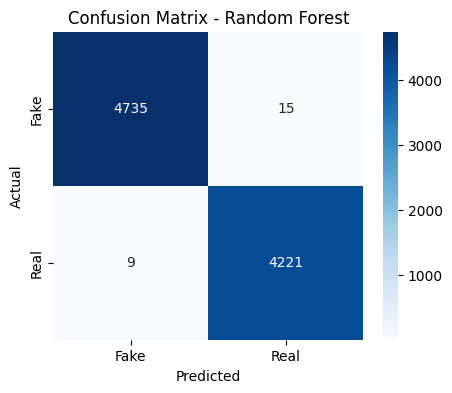

In [10]:
 # Confusion Matrix Visualization
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
plt.title(f"Confusion Matrix - {name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy",
    "Fake_Precision", "Fake_Recall", "Fake_F1",
    "Real_Precision", "Real_Recall", "Real_F1"
])

print("\nModel Comparison Table:")
print(results_df)


Model Comparison Table:
                 Model  Accuracy  Fake_Precision  Fake_Recall   Fake_F1  \
0          Naive Bayes  0.928953        0.932842     0.932842  0.932842   
1  Logistic Regression  0.985969        0.988795     0.984632  0.986709   
2        Decision Tree  0.994209        0.993902     0.995158  0.994530   
3        Random Forest  0.997327        0.998103     0.996842  0.997472   

   Real_Precision  Real_Recall   Real_F1  
0        0.924586     0.924586  0.924586  
1        0.982824     0.987470  0.985142  
2        0.994555     0.993144  0.993849  
3        0.996459     0.997872  0.997165  


In [ ]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 300
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Build RNN Model
model_rnn = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=max_len),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
history = model_rnn.fit(X_train_pad, y_train, epochs=5, batch_size=64,
                        validation_data=(X_test_pad, y_test))

# Evaluate
loss, acc = model_rnn.evaluate(X_test_pad, y_test)
print("\nRNN Model Accuracy:", acc)

c:\Users\suman\Sumanth M\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 427s 754ms/step - accuracy: 0.9335 - loss: 0.1773 - val_accuracy: 0.9728 - val_loss: 0.0822
Epoch 2/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 544s 968ms/step - accuracy: 0.9731 - loss: 0.0846 - val_accuracy: 0.9644 - val_loss: 0.1079
Epoch 3/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 634s 1s/step - accuracy: 0.9767 - loss: 0.0724 - val_accuracy: 0.9839 - val_loss: 0.0534
Epoch 4/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 649s 1s/step - accuracy: 0.9891 - loss: 0.0355 - val_accuracy: 0.9884 - val_loss: 0.0447
Epoch 5/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 615s 1s/step - accuracy: 0.9948 - loss: 0.0173 - val_accuracy: 0.9898 - val_loss: 0.0362
281/281 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9898 - loss: 0.0362

RNN Model Accuracy: 0.9897550344467163


In [25]:
# Making predictions on test data
y_pred_probs = model_rnn.predict(X_test_pad)

# Take a few sample predictions
for i in range(5):
    prob = y_pred_probs[i][0]
    label = "Real News" if prob > 0.5 else "Fake News"
    print(f"Sample {i+1}: Predicted Value = {prob:.2f} → {label}")

281/281 ━━━━━━━━━━━━━━━━━━━━ 24s 83ms/step
Sample 1: Predicted Value = 0.00 → Fake News
Sample 2: Predicted Value = 1.00 → Real News
Sample 3: Predicted Value = 0.00 → Fake News
Sample 4: Predicted Value = 0.00 → Fake News
Sample 5: Predicted Value = 1.00 → Real News


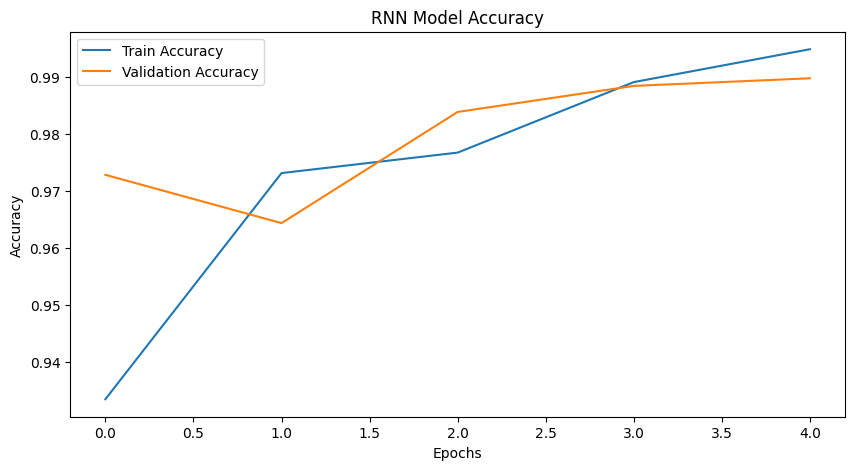

In [13]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("RNN Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



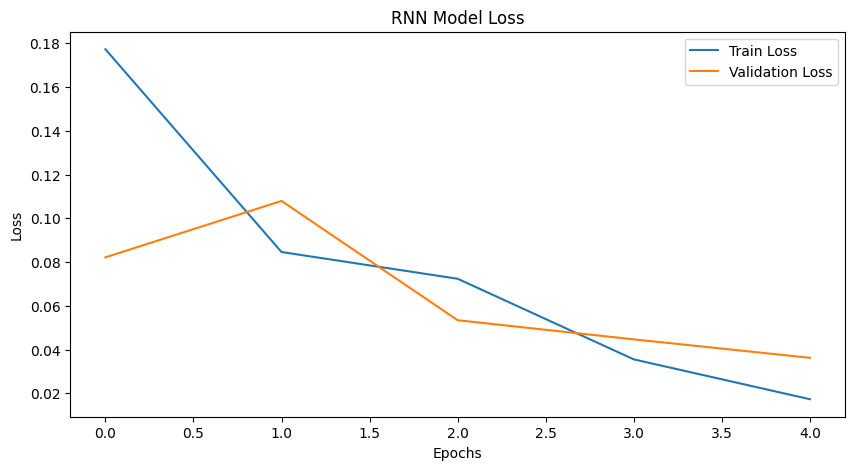

In [14]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("RNN Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()